<a href="https://colab.research.google.com/github/okana2ki/multiV/blob/main/kmeans_SSDSE_C2_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習帳：[非階層的クラスタリング](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb) より

## 確認問題

[教育用標準データセット（SSDSE）](https://www.nstac.go.jp/SSDSE/)に収録されている都道府県庁所在市別・家計消費データ（SSDSE-C）に対してクラスタ分析を適用し、消費行動が類似している都道府県のクラスタを作りたい。

### (1) データセットの読み込み

このデータセットを読み込み、各都道府県庁所在地を特徴ベクトルで表現せよ。

In [1]:
# prompt: https://www.nstac.go.jp/sys/files/SSDSE-C-2026.csv を読み込み、先頭5行を表示

import pandas as pd
import urllib.request
import io

url = 'https://www.nstac.go.jp/sys/files/SSDSE-C-2026.csv'

# よりブラウザに近いリクエストヘッダーを設定
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'})

try:
    with urllib.request.urlopen(req) as response:
        csv_data = response.read()
    # Shift-JISで読み込み
    df = pd.read_csv(io.BytesIO(csv_data), encoding='shift_jis')
    display(df.head())
except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("サーバーにアクセスがブロックされている可能性があります。手動でダウンロードしてアップロードしてください。")

,SSDSE-C-2026,2023-2025年,City,LA03,LB00,LB01,LB011001,LB012001,LB012002,LB013001,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
0,地域コード,都道府県,市,世帯人員,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
1,R00000,全国,全国,2.88,1085539,91820,30111,10713,23530,3777,...,16577,26615,5121,13378,8444,6446,54738,10261,18073,7756
2,R01100,北海道,札幌市,2.77,1007628,91994,35984,9366,19957,3515,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
3,R02201,青森県,青森市,2.79,1010524,87921,29339,9621,19671,3387,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
4,R03201,岩手県,盛岡市,2.85,1042728,86816,28660,8716,20144,3730,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972


* ダウンロードしてきたファイルを読み込んでもよいのですが、今回は、サイトから直接ファイルを読み込むことにしました。

* 最近、SSDSEのサーバーの仕様が変わり、プログラムからのダウンロードがブロックされるようになったので、それに対処できるコードにしてあります。

* いきなり、特徴ベクトル表現をしてもよいのですが、**まず、読み込むだけ**、というように**小分けに指示**して、**内容を確認しながら**進むことにしました。**複雑なプログラムを作るときは、段階を踏んで作っていく方がお勧め**です。（AIの能力が急速に高まりつつあるので、複雑なプログラムを一気に作れるようになる方向にはありますが）

* 今回のような依頼の仕方をすると、shift_jisであることは、AIが適切に判断してくれることが多いようです。shift_jisで読み込まなかった場合は、エラーが出ますが、エラーをAIに説明してもらったり対処してもらうのは容易でしょう。

* **ここで読み込んだ内容を確認しておく**と、この後、特徴ベクトルを抽出したときに、うまくできているかの確認が容易です。

- 以下で、特徴ベクトル表現を作ります。




In [2]:
# prompt: 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現し、先頭5行を表示

# 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現
df_features = df.iloc[2:, 4:]

# 先頭5行を表示
df_features.head()


,LB00,LB01,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,1007628,91994,35984,9366,19957,3515,2057,1558,4663,6428,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
3,1010524,87921,29339,9621,19671,3387,2771,1288,6192,8326,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
4,1042728,86816,28660,8716,20144,3730,2603,1423,6475,7023,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972
5,1065052,86729,26933,10030,21414,3400,2138,1616,5185,7189,...,17554,28348,3858,14261,7886,6238,24913,10027,20529,10741
6,1030621,82086,24802,8532,18253,3828,3943,1361,6331,7215,...,16134,19689,2598,8868,8536,4181,25919,6027,16841,13111


* **2行目以降という指示**なしに自動で判断させることは難しいようでした。1行目の全国を除こうと思ったので、こうしました。なお、0行目から始まるので、その数え方で指示しましたが、1行目から始まる数え方で指示してもAIが判断してくれることもあると思います。

* **4列目以降**というのを指示なしで自動判断するのも難しいようです。食料（合計）の列以降、というつもりです。**「消費行動の類似性でクラスタリングせよ」というお題**なので、「世帯人員」列を除くのは妥当だと思います。「食料（合計）」は、それ以降の列の合計なので、冗長な特徴になっていると思われるので、これも除くという考えもあると思います。また、「穀類」のような小計の列もあり、これも除いた方がよいかもしれませんが、どの列を除くかの指示が面倒かなと思い、小計も合計も含まれたままにしました。（実は、これが後で問題になります）（後で紹介しますが、実は、ある方法を使うと、小計や合計の列は簡単に除くことができます）

* 丁寧に分析するなら、「世帯人員」で、各品目の支出額を正規化するという分析が望ましいかを検討すべきですが、今回はそれはしていません。各品目の支出額は一世帯当たりで集計されているので、それで正規化した方が消費の特徴を表しているとも言えるし、世帯人数の多少も含めて支出額の特徴を捉えるという考えもあると思います。

* 各品目の支出額は一世帯当たりで集計されている、というようなことは、[SSDSEのHP](https://www.nstac.go.jp/use/literacy/ssdse/)の[**データごとの解説資料**](https://www.nstac.go.jp/sys/files/kaisetsu-C-2026.pdf)に書いてあります。**適切な分析のためには、分析前に解説に目を通しておくことが必要**ですね。

* ここで**抽出した結果を表示して、意図通りにできていることを確認**して、次に進みます。

* 元のデータの0行目の品目名や、2列目の都市名がdf_featuresには含まれておらず、分かりにくくなっているのですが、必要になれば、後で回復できるはずなので、ここはそのままにして進みます。

### (2) WCSSのプロット

K-meansクラスタリングを異なるクラスタ数$K$で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

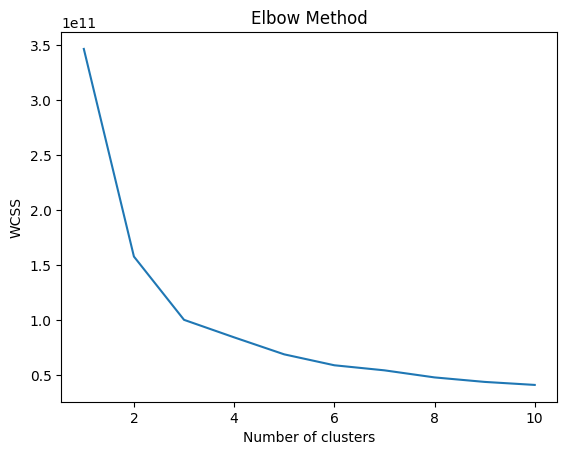

In [3]:
# prompt: K-meansクラスタリングを異なるクラスタ数 K で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# クラスタ数の上限
max_clusters = 10

# クラスタ数ごとのWCSSを格納するリスト
wcss = []

# 異なるクラスタ数でK-meansクラスタリングを実行
for i in range(1, max_clusters + 1):
  kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)  # n_init: 初期化回数（何回試すか）を明示的に指定することで警告メッセージを回避
  kmeans.fit(df_features)

  # クラスタ内平方和（WCSS）をリストに追加
  wcss.append(kmeans.inertia_)

# クラスタ数とWCSSをプロット
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


↑このグラフが何のことか分からない人は、[この資料](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb)の目次から「クラスタ数の選び方」を参照。

* 以上のように、問題文をそのままプロンプトに入力すると、うまくプログラミングできた！と一瞬喜んでしまうかもしれませんが、ここで、落ち着いて、データを見直してみましょう。

* すると、**品目によって、支出額の多少に開きがある**のはもちろん、小計や合計もあるので、**特に一番大きい「食料（合計）」という特徴量が大きく効いて**、**ほぼ「食料（合計）」の多少だけでクラスタリングが決まってしまっているのではないか**と想像できます。

* これでは、題意であった「消費行動の類似性」によりクラスタリングしたことにはなっていませんよね。ほぼ合計額だけを考慮してクラスタリングしたことになってしまっていると思います。

* このような結果になってしまっていることをちゃんとデータで確認するには、このまま次の(3)に進んで、各クラスタに属する都市名を洗い出すか、または、**クラスタごとの「食料（合計）」の箱ひげ図**を描くと、確認できると思います。ぜひ、この確認にチャレンジしてみて下さい。**←今日の宿題その１**

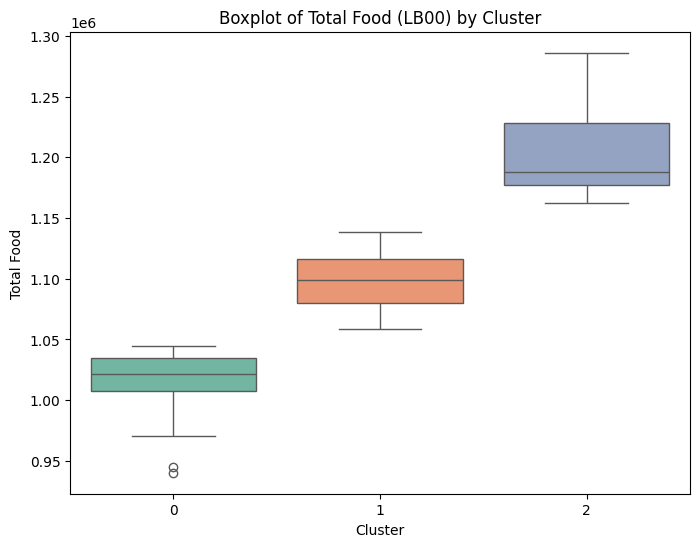

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# クラスタ数を設定（エルボー図などを参考に適宜変更してください）
k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
clusters = kmeans.fit_predict(df_features)

# 食料（合計）の列は 'LB00'。
# 計算用に数値型（float）に変換して可視化用のデータフレームを作成します
df_plot = pd.DataFrame({
    'Cluster': clusters,
    'Total_Food': df.loc[2:, 'LB00'].astype(float)
})

# 箱ひげ図の描画
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='Total_Food', data=df_plot, palette='Set2', hue='Cluster', legend=False)
plt.title('Boxplot of Total Food (LB00) by Cluster') # 日本語フォント未導入環境を考慮し英語表記にしています
plt.xlabel('Cluster')
plt.ylabel('Total Food')
plt.show()

上記の箱ひげ図から、クラスターごとに、「食料（合計）」の額がきれいに分かれていることが分かります。これは、「食料（合計）」によってクラスタリングされたことを示すと考えてよいでしょう。

各クラスタに属する都市名も確認しておきましょう↓

In [5]:
# 各クラスタに属する都市名を抽出して表示
cities = df.loc[2:, 'City'].values

for i in range(k):
    cluster_cities = cities[clusters == i]
    print(f"【クラスタ {i}】")
    print(", ".join(cluster_cities))
    print()


【クラスタ 0】
札幌市, 青森市, 盛岡市, 秋田市, 水戸市, 前橋市, 福井市, 甲府市, 岐阜市, 津市, 和歌山市, 鳥取市, 松江市, 山口市, 徳島市, 高松市, 松山市, 高知市, 佐賀市, 長崎市, 大分市, 宮崎市, 鹿児島市, 那覇市

【クラスタ 1】
仙台市, 山形市, 福島市, 宇都宮市, 新潟市, 金沢市, 長野市, 静岡市, 大津市, 京都市, 大阪市, 神戸市, 奈良市, 岡山市, 広島市, 福岡市, 熊本市

【クラスタ 2】
さいたま市, 千葉市, 東京都区部, 横浜市, 富山市, 名古屋市



* さて、この「大きな値の特徴量にクラスタリング結果が左右されてしまう」という問題は、どう対処したらよいでしょうか？

* まずやるべきことは、**小計や合計をデータから除く**ことです。**←今日の宿題その２**。これは「消費行動の類似性」によりクラスタリングするという目的から考えると、必要な操作だと思います。ただ、ちょっと、除くための指示が面倒そうに思うかもしれません。

* 合計や小計をデータから除くのは、個別にこの列を除けと指示しなくても、一括指示することができそうです。どうしてかというと、一番上の行（各列の識別記号）を見ると、合計や小計は、LB00やLB01のような短かいコードが割り振られているからです。AIと相談すると具体的にどうすればよいかを教えてくれると思います。さらにいうと、データの形式を説明するPDFファイルを添付してAIに頼むとより確実にやりたいことが伝わります。なお、ただし、合計や小計も特徴量だと捉えてクラスタリングするという考えもありかなとも思います。

In [6]:
# 列名の長さが4文字（例: LB00, LB01など）の列を除外し、個別品目のみのデータを作成
df_features_filtered = df_features.loc[:, df_features.columns.str.len() > 4]

# 結果の先頭5行を表示して確認
df_features_filtered.head()


,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,LB013006,LB013007,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,35984,9366,19957,3515,2057,1558,4663,6428,2207,666,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
3,29339,9621,19671,3387,2771,1288,6192,8326,2491,549,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
4,28660,8716,20144,3730,2603,1423,6475,7023,2342,792,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972
5,26933,10030,21414,3400,2138,1616,5185,7189,2167,790,...,17554,28348,3858,14261,7886,6238,24913,10027,20529,10741
6,24802,8532,18253,3828,3943,1361,6331,7215,2379,613,...,16134,19689,2598,8868,8536,4181,25919,6027,16841,13111


* 続いてやるべきことは、**データを前処理してから、クラスタリング**を行うことです。この前処理は、上記にしたがって、個別の品目の支出額だけを残したデータとした場合も、それらの支出額の間に大き目の開きがあるので、有効に働くと思いますし、合計や小計を残したまま分析するときは必須となります。

* どのような前処理をするとよいか、ぜひ考えて、それを実行してみて下さい。その後、クラスタリングを実行して、結果を前処理しなかった場合と比べて下さい。**←今日の宿題その３**。AIに質問しても、おそらく正しい前処理を教えてくれると思います。前回、すでに、この前処理が加えられていた人も、AIの判断で自動で加えられたのであれば、なぜそれが必要なのかが、「今日の宿題その1」で分かったと思います。

* 前処理のヒントを書いておくと、「標準化」です。「標準化」と「正規化」については、[ここ](https://qiita.com/oki_kosuke/items/02ec7bee92c85cf10ac2)を参照して**内容やそれをする理由を理解してから**、プログラムを書いて実行して下さい。キーワードだけ聞いて、AIにプログラムを頼んでおしまい、では力がつきません。AIに理由とかも尋ねながらプログラミングするという勉強スタイルであれば、それでいいのですが。

↓下記のセルで標準化（平均を0、分散を1とするスケーリング）を施します。

In [7]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# StandardScalerのインスタンスを作成
scaler = StandardScaler()

# df_features_filteredを標準化
# fit_transformはNumPy配列を返すため、扱いやすいようにDataFrameに変換して列名やインデックスを保持します
df_features_std = pd.DataFrame(
    scaler.fit_transform(df_features_filtered),
    columns=df_features_filtered.columns,
    index=df_features_filtered.index
)

# 標準化されたデータの先頭5行を表示して確認
df_features_std.head()


,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,LB013006,LB013007,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,1.830252,-0.900096,-1.325127,-0.344644,-0.554960,0.520307,-0.006823,0.723590,-0.671665,0.101931,...,0.386494,-0.541705,-0.754322,1.311707,-0.311752,-1.345443,-1.029091,-0.738328,0.540895,0.805650
3,0.006552,-0.726051,-1.445159,-0.534167,0.771112,-1.228288,1.938819,3.000756,0.074145,-0.570958,...,-0.442374,-1.602419,-1.006102,-0.905975,-0.708093,-1.611208,-1.365804,-1.837494,-1.159911,-2.304705
4,-0.179798,-1.343740,-1.246644,-0.026305,0.459095,-0.353991,2.298934,1.437454,-0.317143,0.826580,...,-0.494332,-2.000755,-1.504767,-1.390230,-0.511560,-1.252335,0.061108,-0.871937,0.444052,0.455671
5,-0.653768,-0.446897,-0.713636,-0.514918,-0.404523,0.895931,0.657419,1.636616,-0.776709,0.815077,...,0.474612,0.184451,-0.603145,0.260847,-0.424758,-0.066335,-1.136777,0.260243,0.445628,0.390103
6,-1.238615,-1.469326,-2.040281,0.118798,2.947801,-0.755520,2.115695,1.667810,-0.219977,-0.202882,...,-0.023902,-1.172429,-1.288334,-1.033941,-0.158620,-1.925787,-1.084341,-1.293349,-0.200230,1.062812


標準化されたデータを用いて、エルボー法で最適なクラスタ数を検討します。

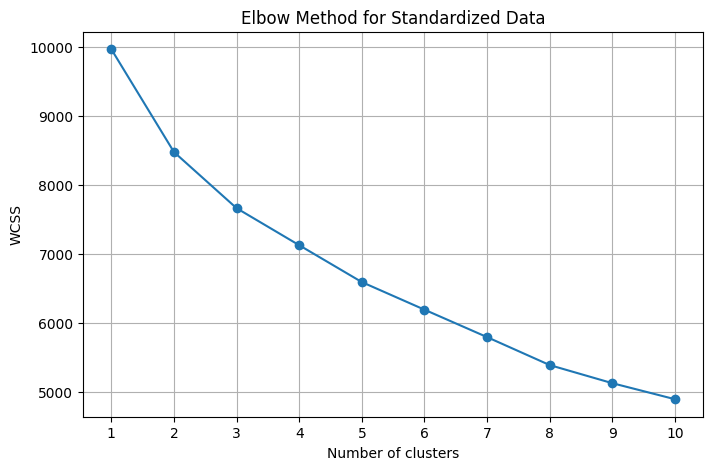

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# クラスタ数の上限
max_clusters = 10

# クラスタ数ごとのWCSSを格納するリスト
wcss_std = []

# 異なるクラスタ数でK-meansクラスタリングを実行
for i in range(1, max_clusters + 1):
    # n_initを明示的に指定して警告を回避
    kmeans_std = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans_std.fit(df_features_std)
    wcss_std.append(kmeans_std.inertia_)

# クラスタ数とWCSSをプロット
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters + 1), wcss_std, marker='o')
plt.title('Elbow Method for Standardized Data')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()

### (3) K-meansクラスタリング

(2)の結果に基づき、クラスタ数$K$を適当に選び、K-meansクラスタリングを実行せよ。$1$から$K$までの各クラスタに対して、それぞれ所属する都道府県庁所在地を明らかにせよ。**←今日の宿題その４**

エルボー図からは、明確に肘のように曲がった点は存在しないので、K=３，５，７，９の４通りの場合に、それぞれ、$1$から$K$までの各クラスタに対して、それぞれ所属する都道府県庁所在地を明らかにするコードを作成する。

In [9]:
from sklearn.cluster import KMeans

# 検討するクラスタ数Kのリスト
k_values = [3, 5, 7, 9]
# 都市名の取得
cities = df.loc[2:, 'City'].values

for k in k_values:
    print(f"========== K={k} の場合 ==========")
    # 標準化されたデータ(df_features_std)を用いてK-meansクラスタリング
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(df_features_std)

    # 1からKまでの各クラスタに対して所属する都市名を表示
    for i in range(k):
        cluster_cities = cities[clusters == i]
        # 表示上はクラスタ番号を1からKにします(内部のインデックスは0からk-1)
        print(f"【クラスタ {i+1}】 ({len(cluster_cities)}都市)")
        print(", ".join(cluster_cities))
        print()
    print("\n")

========== K=3 の場合 ==========
【クラスタ 1】 (20都市)
前橋市, 福井市, 津市, 和歌山市, 鳥取市, 松江市, 岡山市, 山口市, 徳島市, 高松市, 松山市, 高知市, 福岡市, 佐賀市, 長崎市, 熊本市, 大分市, 宮崎市, 鹿児島市, 那覇市

【クラスタ 2】 (12都市)
札幌市, 青森市, 盛岡市, 仙台市, 秋田市, 山形市, 福島市, 水戸市, 新潟市, 富山市, 甲府市, 長野市

【クラスタ 3】 (15都市)
宇都宮市, さいたま市, 千葉市, 東京都区部, 横浜市, 金沢市, 岐阜市, 静岡市, 名古屋市, 大津市, 京都市, 大阪市, 神戸市, 奈良市, 広島市



========== K=5 の場合 ==========
【クラスタ 1】 (1都市)
那覇市

【クラスタ 2】 (4都市)
水戸市, 宇都宮市, 前橋市, 甲府市

【クラスタ 3】 (14都市)
さいたま市, 千葉市, 東京都区部, 横浜市, 富山市, 金沢市, 岐阜市, 静岡市, 名古屋市, 大津市, 京都市, 大阪市, 神戸市, 奈良市

【クラスタ 4】 (9都市)
札幌市, 青森市, 盛岡市, 仙台市, 秋田市, 山形市, 福島市, 新潟市, 長野市

【クラスタ 5】 (19都市)
福井市, 津市, 和歌山市, 鳥取市, 松江市, 岡山市, 広島市, 山口市, 徳島市, 高松市, 松山市, 高知市, 福岡市, 佐賀市, 長崎市, 熊本市, 大分市, 宮崎市, 鹿児島市



========== K=7 の場合 ==========
【クラスタ 1】 (1都市)
高知市

【クラスタ 2】 (18都市)
富山市, 金沢市, 福井市, 岐阜市, 名古屋市, 津市, 大津市, 京都市, 大阪市, 神戸市, 奈良市, 和歌山市, 鳥取市, 松江市, 岡山市, 広島市, 徳島市, 高松市

【クラスタ 3】 (9都市)
山口市, 松山市, 福岡市, 佐賀市, 長崎市, 熊本市, 大分市, 宮崎市, 鹿児島市

【クラスタ 4】 (1都市)
那覇市

【クラスタ 5】 (4都市)
さいたま市, 千葉市, 東京都区部, 横浜市

【クラスタ 6】 (6都市)
水戸市, 宇都宮市, 前橋市, 甲府市, 長野市, 静岡市

【クラス

K=3の場合の食料（合計）の箱ひげ図を描いて、元のデータのままクラスタリングしたときの箱ひげ図と比べてみましょう。

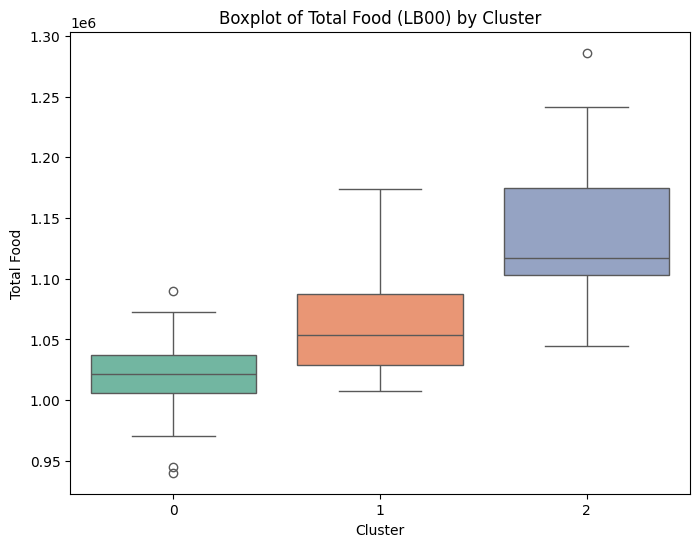

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# クラスタ数を設定（エルボー図などを参考に適宜変更してください）
k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
clusters = kmeans.fit_predict(df_features_std)

# 食料（合計）の列は 'LB00'。
# 計算用に数値型（float）に変換して可視化用のデータフレームを作成します
df_plot = pd.DataFrame({
    'Cluster': clusters,
    'Total_Food': df.loc[2:, 'LB00'].astype(float)
})

# 箱ひげ図の描画
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='Total_Food', data=df_plot, palette='Set2', hue='Cluster', legend=False)
plt.title('Boxplot of Total Food (LB00) by Cluster') # 日本語フォント未導入環境を考慮し英語表記にしています
plt.xlabel('Cluster')
plt.ylabel('Total Food')
plt.show()

元のデータの箱ひげ図は、食料（合計）の値で各クラスタが完全に分離していた（すなわち、食料（合計）だけでクラスタ分けできた）のに対して、前処理の後では、**クラスタ分けに食料（合計）が効いているものの、それだけで決まっているのではない**ことが分かります。

## 演習問題１（今日の宿題その５）

以上のデータ（合計や小計を除いて、標準化したもの）を、階層的クラスタリングしなさい（デンドログラムを書きなさい）

ウォード法（Ward's method）を用いて階層的クラスタリングを実行します。

In [ ]:
!pip install japanize-matplotlib

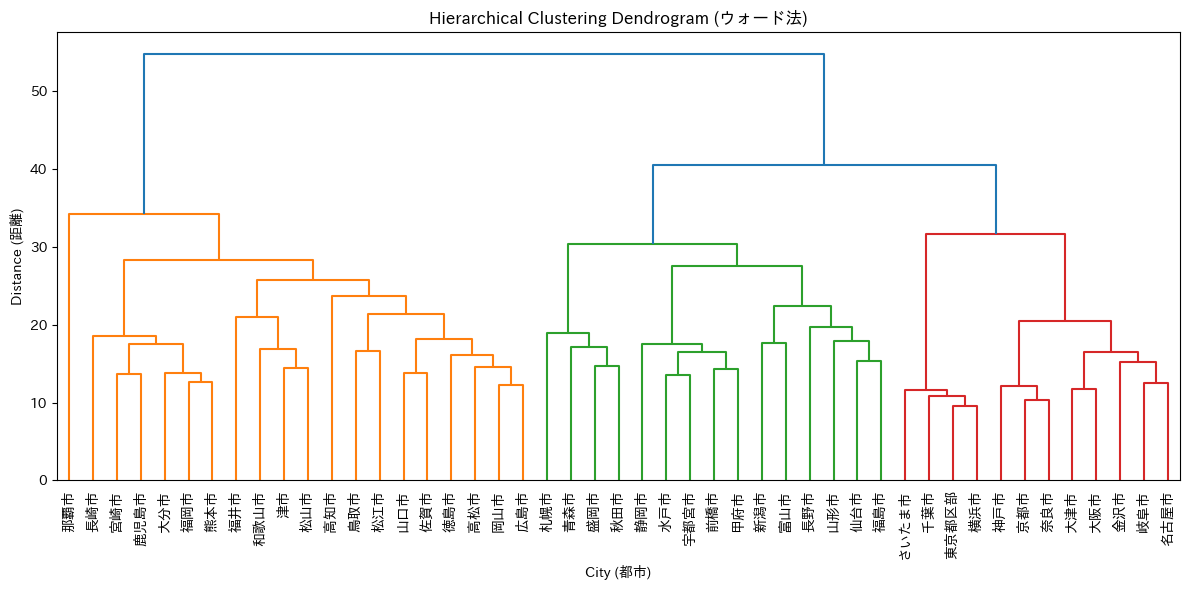

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import japanize_matplotlib

# ウォード法による階層的クラスタリングの実行
# df_features_std は標準化および小計・合計列を除外したデータです
Z = linkage(df_features_std, method='ward')

# デンドログラムの描画
plt.figure(figsize=(12, 6))
# labelsに都市名(cities)を指定
dendrogram(Z, labels=cities, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (ウォード法)')
plt.xlabel('City (都市)')
plt.ylabel('Distance (距離)')
plt.tight_layout()
plt.show()

## 演習問題２：主成分分析（今日の宿題その６）

### 2-1: 合計や小計を除いて、標準化したデータに対して、第20主成分まで主成分分析を行いなさい。

In [13]:
from sklearn.decomposition import PCA
import pandas as pd

# 第20主成分まで主成分分析を行う
pca = PCA(n_components=20)

# 標準化されたデータを主成分分析にかける
pca_features = pca.fit_transform(df_features_std)

# 結果を見やすくするためDataFrameに変換（インデックスは元のデータを保持）
df_pca = pd.DataFrame(
    pca_features,
    columns=[f'PC{i+1}' for i in range(20)],
    index=df_features_std.index
)

# 変換後のデータの先頭5行を表示
df_pca.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
2,0.471602,-6.379644,-1.303711,5.385564,-1.698656,4.521802,-0.604555,-2.528241,-5.686836,-2.229009,-1.054765,5.270093,-1.269925,-3.216832,-0.628875,-0.042158,-1.305522,5.012254,1.170822,0.367476
3,2.596008,-12.192854,3.281390,8.165109,-4.412892,4.721058,0.284891,-5.523793,3.919865,-1.226637,0.395535,1.252510,0.167607,0.759569,-0.065764,1.029913,2.602637,-1.341704,-1.658063,-1.781299
4,3.884989,-10.148014,1.152107,3.522391,-0.612157,2.913995,-1.376664,1.966761,1.543799,0.143459,1.481280,-2.040391,-1.744346,1.663808,0.833530,-0.605322,1.047459,0.663995,-1.850522,-0.972727
5,5.737548,-4.976185,-1.204725,-1.732118,0.290724,3.012210,0.411383,0.112027,-2.898127,-1.722241,0.566719,-0.442843,2.165368,-0.524215,1.789604,-1.121317,-1.902060,2.088270,2.000080,1.733053
6,4.376717,-8.353618,4.603574,6.991122,1.945663,-0.535745,-2.545406,1.252091,0.222605,2.548255,1.855003,2.090986,-1.287672,-1.228781,0.319195,0.748157,-2.564321,-3.714938,-0.720093,2.435630


#### 主成分得点

- 各サンプル（この場合、各都市）の新しい座標系における値（上の表）
- どのサンプルがどの主成分に強く影響を受けているか、サンプル間の類似性などを把握できる

### 2-2: 主成分の数 k を横軸、累積寄与率を縦軸としてグラフを描画しなさい。

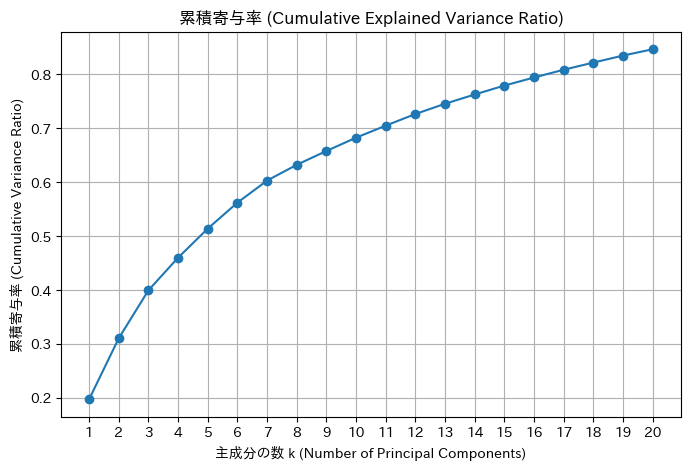

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 累積寄与率の計算
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# グラフの描画
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_variance_ratio, marker='o')
plt.title('累積寄与率 (Cumulative Explained Variance Ratio)')
plt.xlabel('主成分の数 k (Number of Principal Components)')
plt.ylabel('累積寄与率 (Cumulative Variance Ratio)')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

### 2-3: 第1主成分得点を横軸、第2主成分得点を縦軸として、各都道府県庁所在地の消費支出金額を2次元平面上にプロットしなさい。プロットした各点に都市名を付記すること。

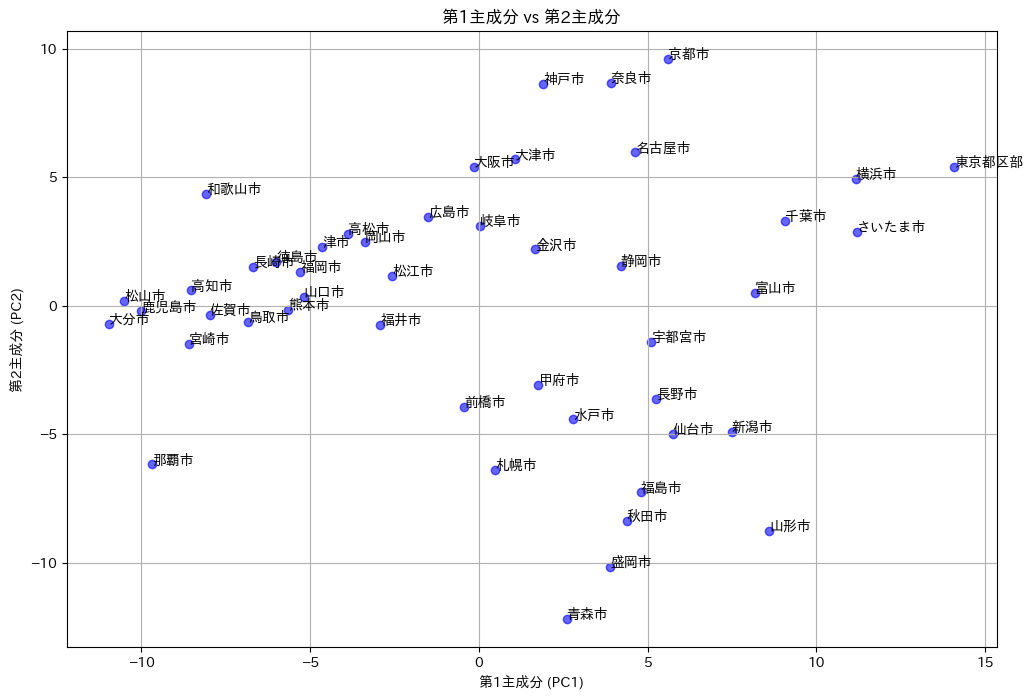

In [15]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(12, 8))

# 第1主成分を横軸、第2主成分を縦軸に散布図をプロット
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='blue', alpha=0.6)

# 各点に都市名を付記
for i, city in enumerate(cities):
    plt.annotate(city, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10)

plt.title('第1主成分 vs 第2主成分')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.grid(True)
plt.show()


#### 主成分負荷量

- 各主成分と元の変数（この場合、各品目の消費支出額）との間の相関
- 各主成分がどのような特徴を表しているのか（特徴量のどのような線形結合か）解釈できる

In [16]:
# 主成分負荷量を表示
print("\n主成分負荷量 (pca.components_):")
# 主成分負荷量の行名をPC1, PC2, ...とする
pca_loading_df = pd.DataFrame(pca.components_, columns=df_features_filtered.columns, index=[f'PC{i+1}' for i in range(pca.components_.shape[0])])
display(pca_loading_df.head())


主成分負荷量 (pca.components_):


,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,LB013006,LB013007,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
PC1,0.019899,0.035210,0.013527,0.043829,0.075111,0.096370,0.097556,0.032171,-0.071331,0.116668,...,0.091670,0.034600,0.081455,0.089459,-0.024267,-0.021411,0.035806,0.087211,0.070788,-0.012416
PC2,-0.021141,0.154951,0.158328,0.034412,-0.051225,0.035378,-0.104093,-0.136943,0.037142,0.032660,...,0.021937,0.094253,0.132944,0.053153,0.039517,0.072948,0.116188,0.133722,0.009896,-0.059883
PC3,-0.083260,0.056702,-0.008788,0.082120,0.092611,-0.039791,0.020514,0.085764,0.122239,-0.036285,...,0.080042,0.040061,-0.004105,-0.022202,0.053392,-0.090990,-0.112233,-0.035411,-0.052087,0.060772
PC4,0.044355,0.007113,0.015161,-0.041009,0.008672,-0.046055,0.070940,-0.002424,-0.022648,0.008115,...,-0.116912,-0.141958,-0.055073,-0.106145,-0.145109,-0.125545,0.052830,-0.048109,-0.080136,-0.101962
PC5,-0.003278,-0.063082,-0.007228,-0.095339,-0.009248,0.107311,-0.030892,-0.023381,0.111872,0.032798,...,-0.033929,-0.002455,-0.068444,-0.022248,0.033246,0.047410,0.046052,-0.001830,0.108063,0.145482


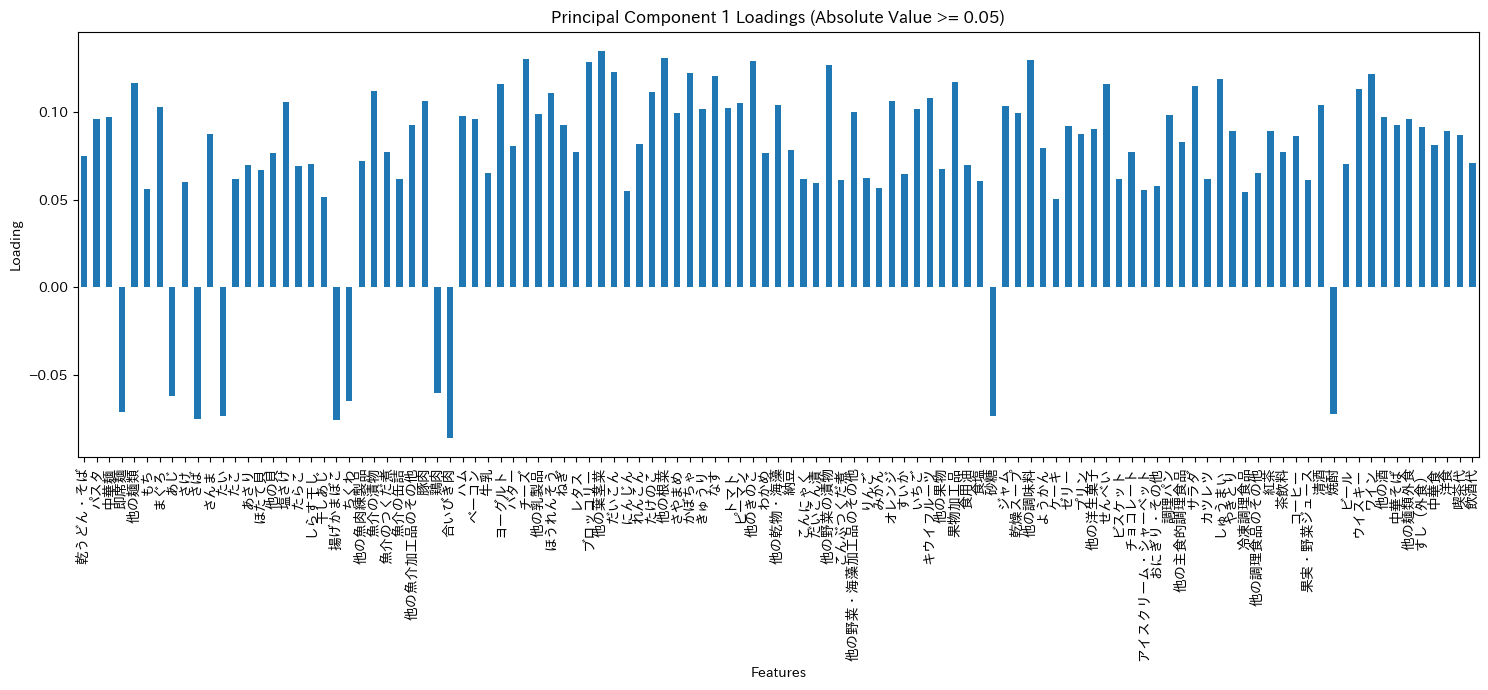

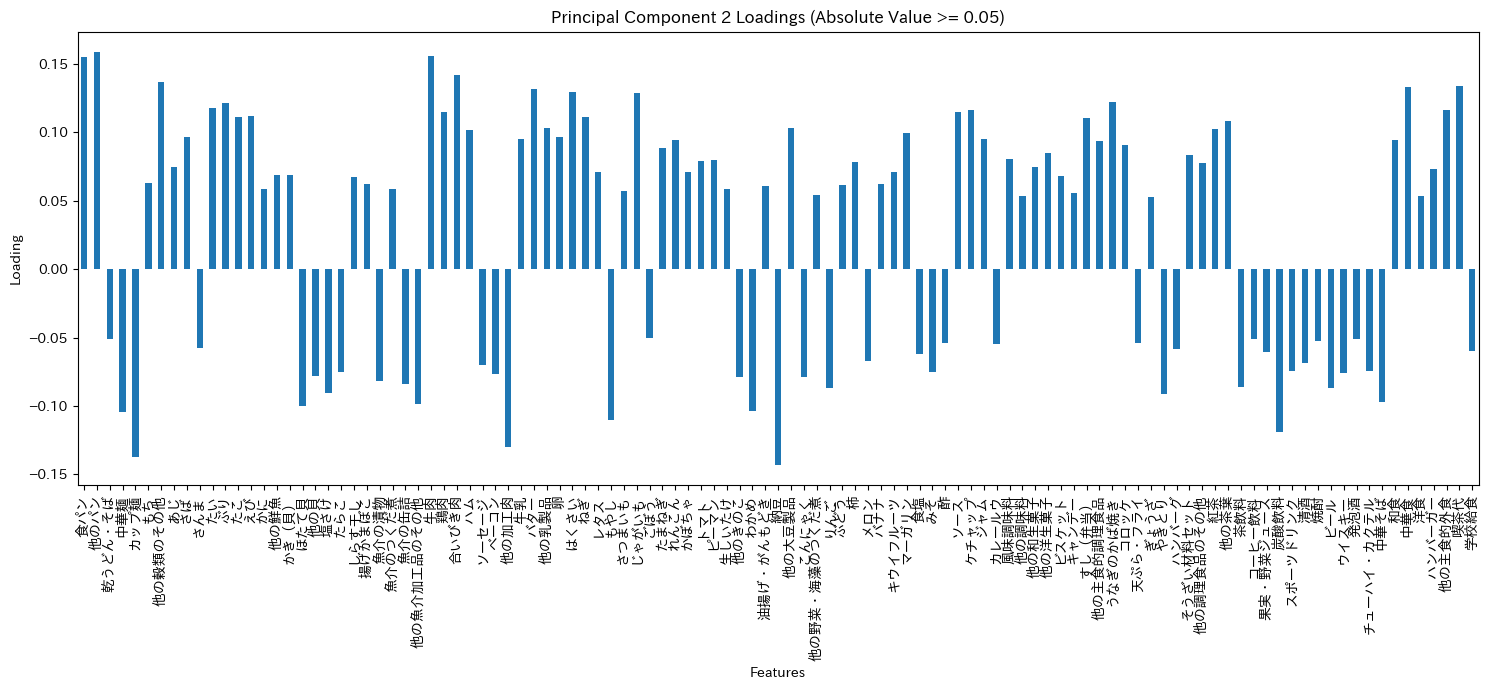

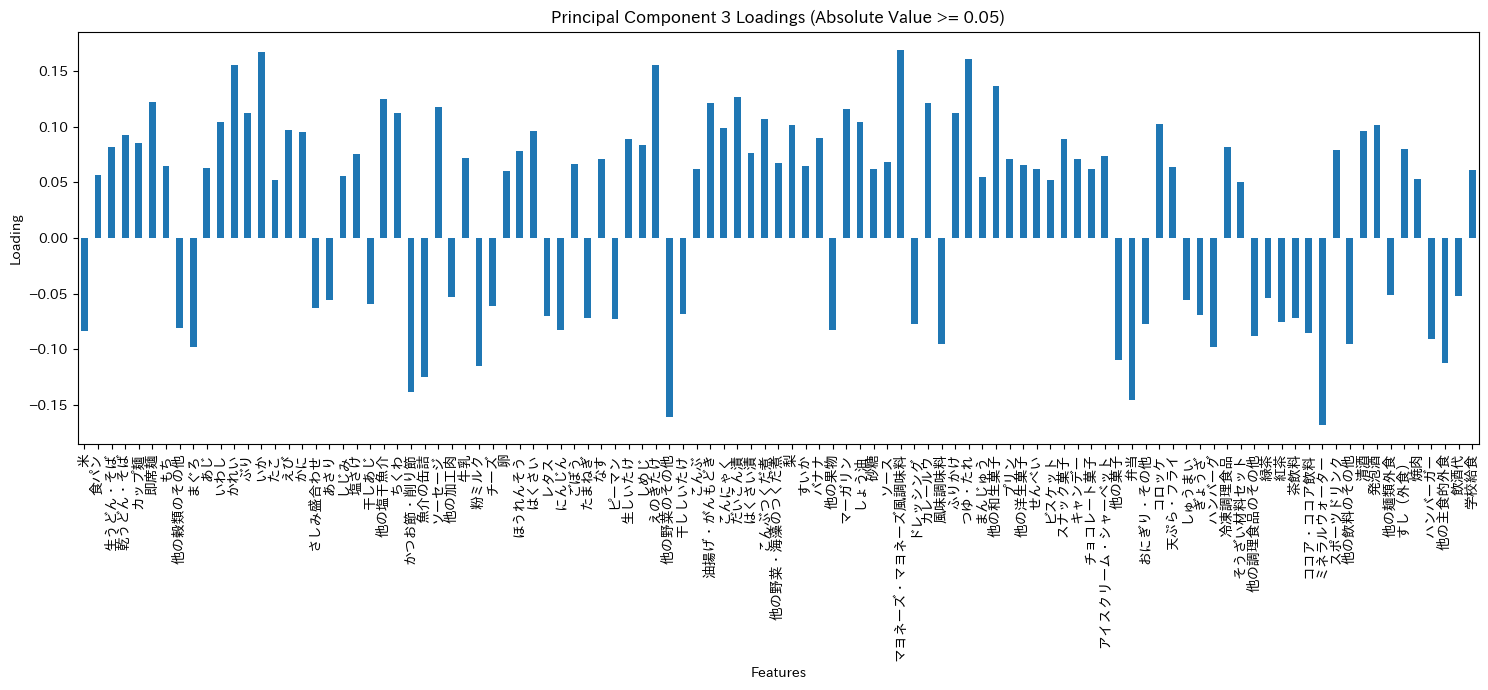

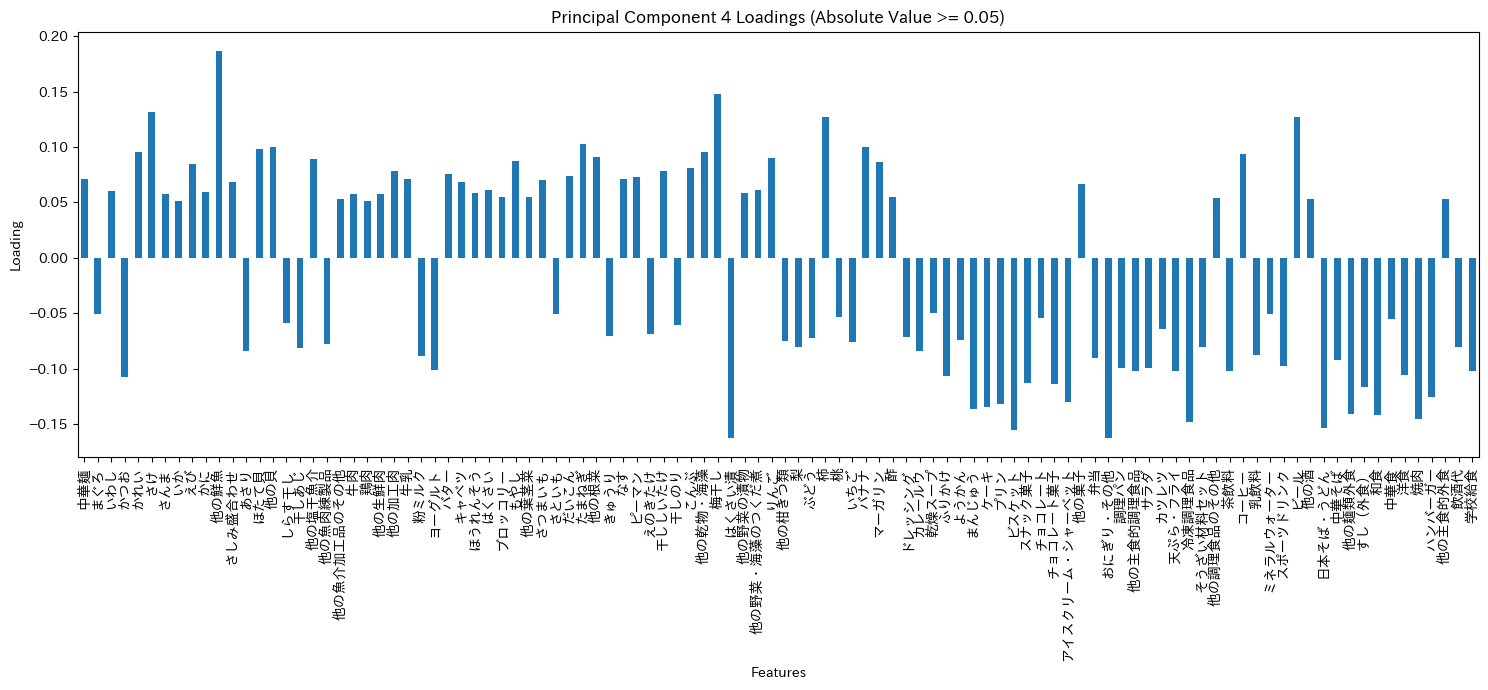

In [17]:
# PC1からPC4の主成分負荷量を可視化
for i in range(1, 5):
    pc_loadings = pca_loading_df.loc[f'PC{i}']

    # 負荷量の絶対値が0.05以上の品目のみを抽出
    significant_loadings = pc_loadings[abs(pc_loadings) >= 0.05]

    # 横軸ラベルとして使用する品目名を取得
    significant_feature_names = [df.iloc[0][col] for col in significant_loadings.index]

    # 棒グラフを作成
    plt.figure(figsize=(15, 7))
    significant_loadings.plot(kind='bar')
    plt.title(f'Principal Component {i} Loadings (Absolute Value >= 0.05)')
    plt.xlabel('Features')
    plt.ylabel('Loading')
    plt.xticks(ticks=range(len(significant_feature_names)), labels=significant_feature_names, rotation=90, ha='center')
    plt.tight_layout()
    plt.show()

カテゴリごとの平均のレーダーチャート

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

# 特徴量をLBxxのカテゴリに分ける
feature_categories = {}
for col in df_features_filtered.columns:
    prefix = col[:4]  # 例: 'LB01', 'LB02', ...
    if prefix not in feature_categories:
        feature_categories[prefix] = []
    feature_categories[prefix].append(col)

# 各カテゴリごとの主成分負荷量の平均値を計算
average_loadings_by_category = pd.DataFrame()
for category, features in feature_categories.items():
    # 該当するカテゴリの特徴量に対応する主成分負荷量を取得
    pca_loading_category = pca_loading_df[features]
    # カテゴリ内の特徴量にわたる平均値を計算
    average_loadings_by_category[category] = pca_loading_category.mean(axis=1)

# 結果の表示
display(average_loadings_by_category.head())


,LB01,LB02,LB03,LB04,LB05,LB06,LB07,LB08,LB09,LB10,LB11,LB12
PC1,0.041366,0.026557,0.014408,0.061418,0.059992,0.059216,0.019618,0.044889,0.054261,0.032437,0.054901,0.050561
PC2,0.029369,0.008974,0.022713,0.055295,0.010032,0.012544,0.014030,0.013195,0.030226,-0.013839,-0.049709,0.044206
PC3,0.024594,0.031147,0.029843,-0.008137,0.020184,0.012791,0.030379,0.041590,-0.014886,-0.024492,0.023315,-0.003231
PC4,0.001348,0.024152,0.037941,-0.005285,0.027005,0.001695,-0.008312,-0.066673,-0.054954,-0.019660,0.037842,-0.096532
PC5,0.004761,-0.006448,0.056028,0.009493,0.036007,-0.003548,0.073193,0.039526,-0.015072,-0.007070,0.035916,0.023081


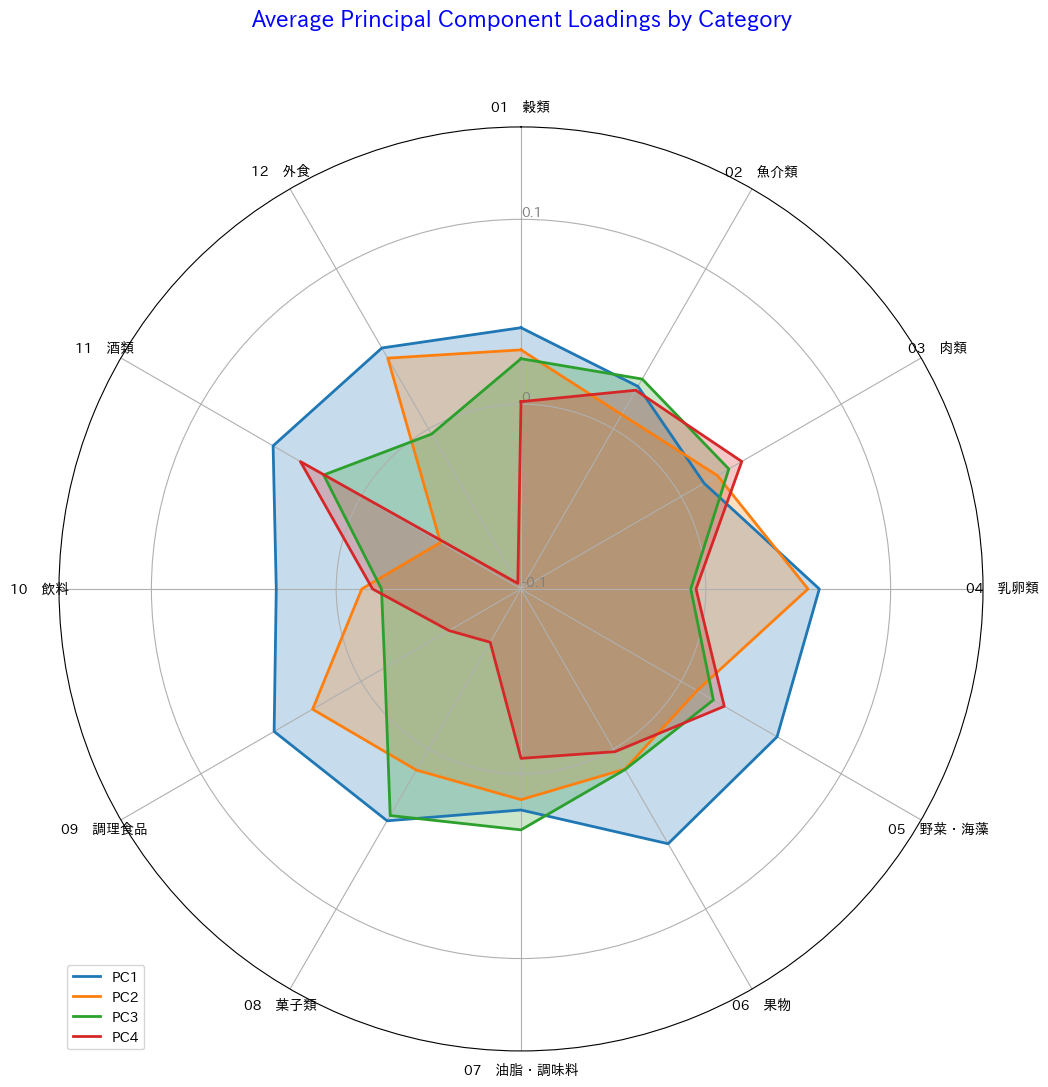

In [22]:
# レーダーチャートの作成

# 使用する主成分の数 (例: 上位4つに変更)
n_components_radar = 4
categories = [df.iloc[0][col] for col in average_loadings_by_category.columns]
N = len(categories)

# 角度の設定
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # 閉じた図にするために最初に戻る

plt.figure(figsize=(12, 12)) # グラフサイズを調整
ax = plt.subplot(111, polar=True)

# 各主成分のレーダーチャートを描画
for i in range(n_components_radar): # 上位4つの主成分を描画
    values = average_loadings_by_category.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'PC{i+1}')
    ax.fill(angles, values, alpha=0.25)

# ラベルの設定
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10) # ラベルサイズを調整

# Y軸ラベルの設定 (目盛りを円状に表示)
ax.set_rlabel_position(0)
plt.yticks([-0.1, 0, 0.1], [-0.1, 0, 0.1], color="grey", size=10) # Y軸の表示範囲を調整
plt.ylim(-0.1, 0.15) # Y軸の範囲を調整（最大値を考慮して少し余裕を持たせる）

plt.title('Average Principal Component Loadings by Category', size=16, color='blue', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

PC1とPC4の主成分負荷量のレーダーチャート（カテゴリ平均でなく個々の品目について）

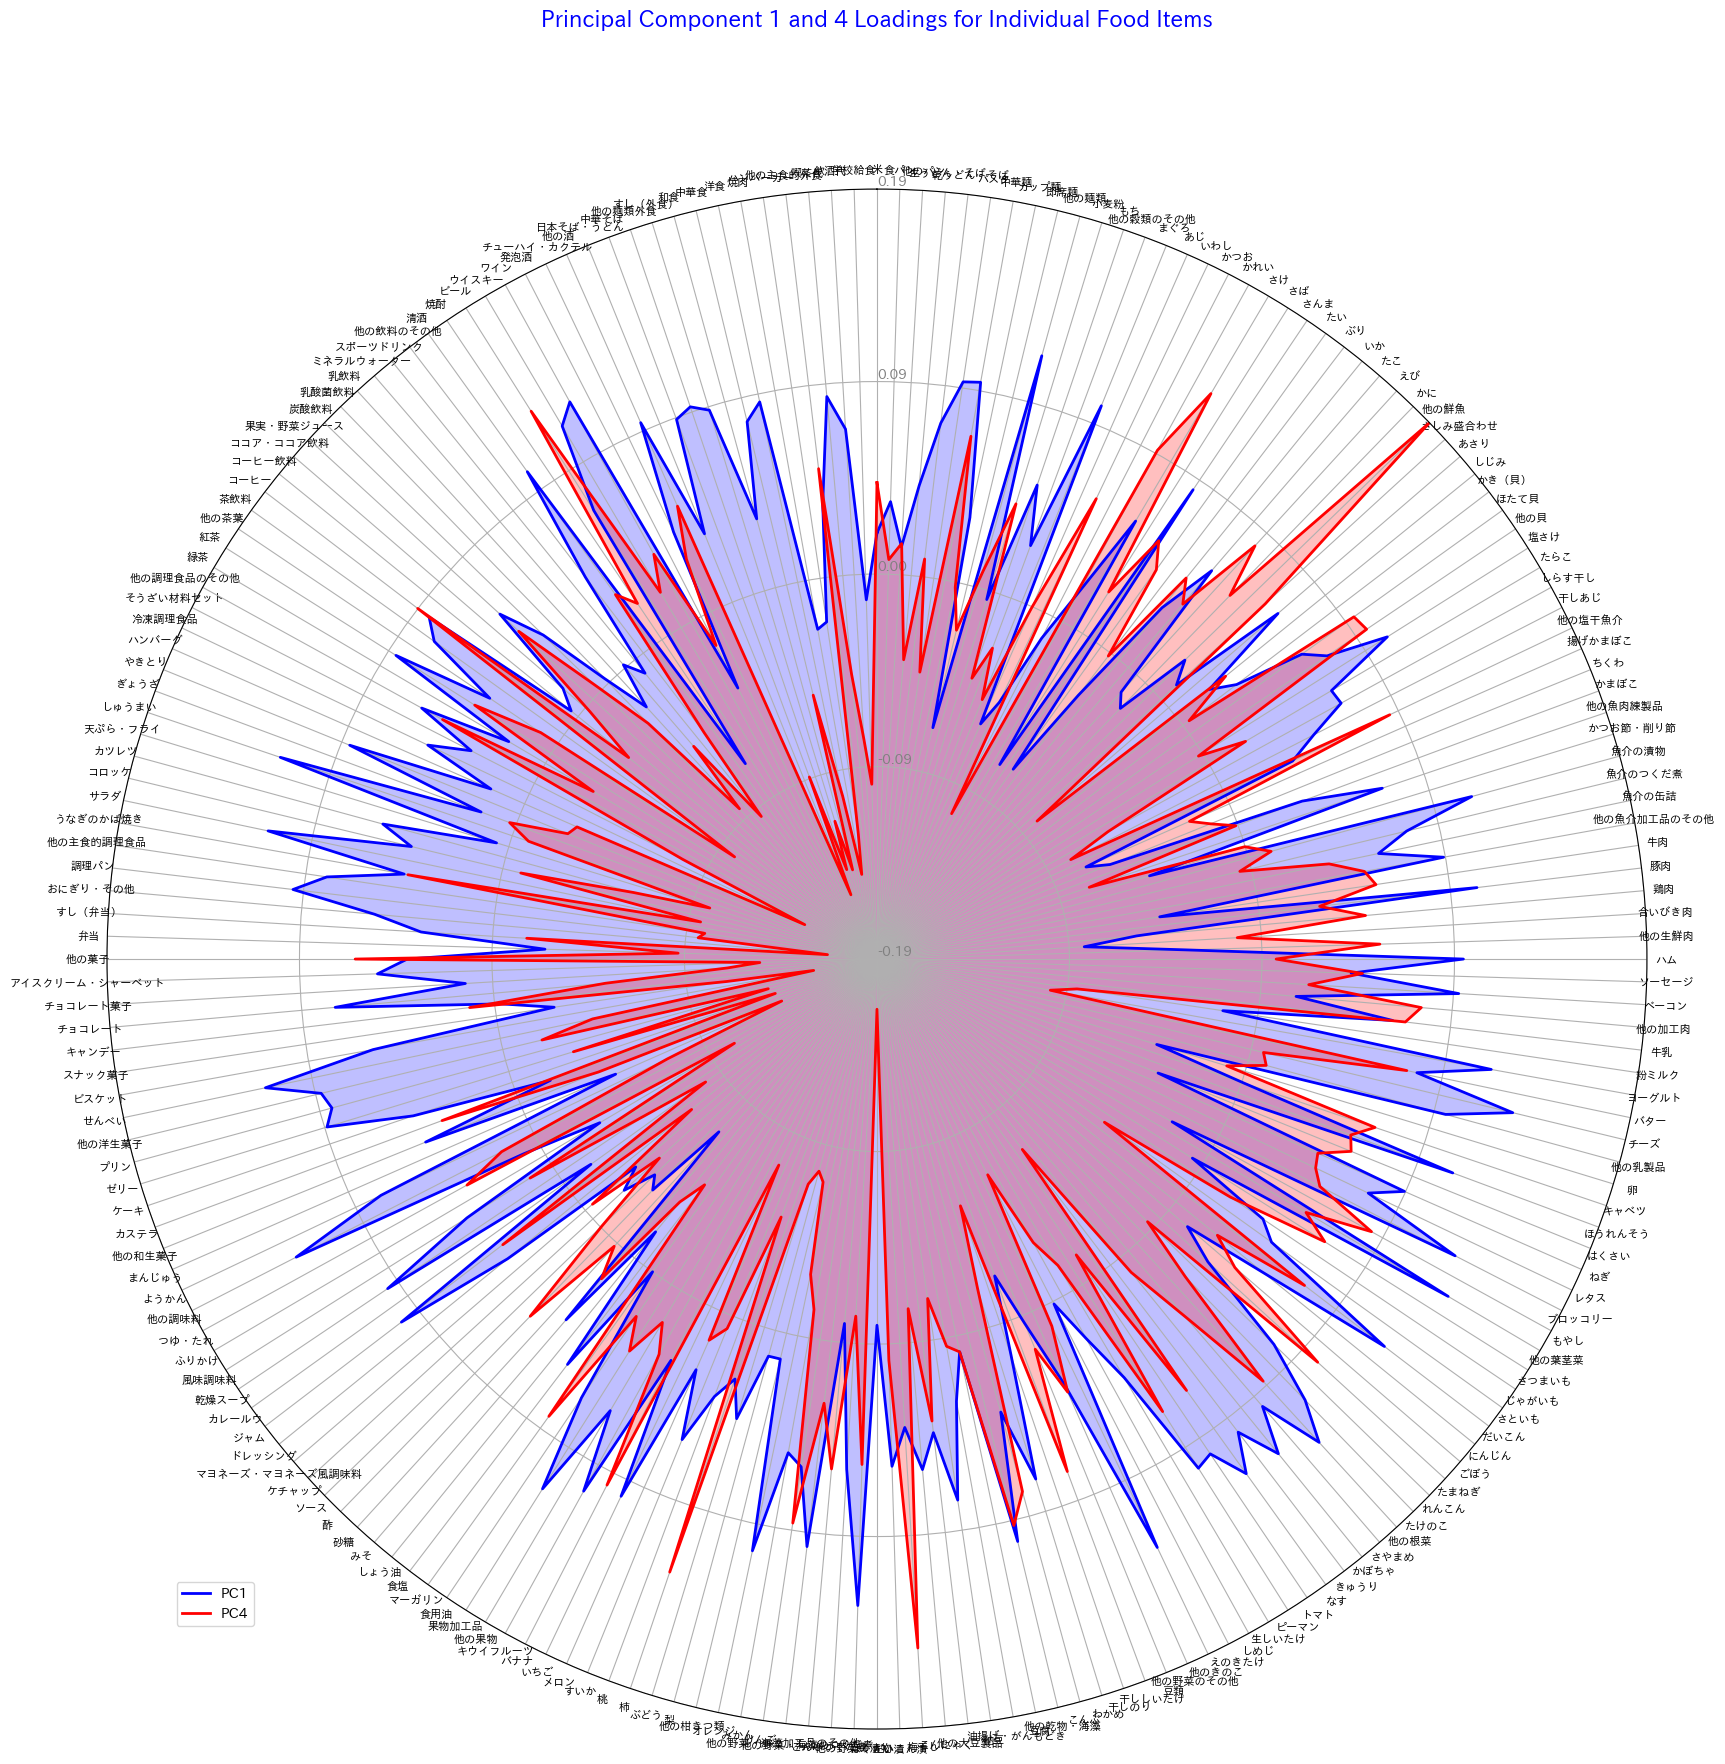

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

# PC1とPC4の主成分負荷量を取得
pc1_loadings = pca_loading_df.loc['PC1']
pc4_loadings = pca_loading_df.loc['PC4']

# 全ての食品項目を取得（PC1とPC4で共通のインデックスを使用）
food_items = pc1_loadings.index.tolist()
pc1_values = pc1_loadings.tolist()
pc4_values = pc4_loadings.tolist()

N = len(food_items)

# 角度の設定
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # 閉じた図にするために最初に戻る
pc1_values += pc1_values[:1]
pc4_values += pc4_values[:1]


plt.figure(figsize=(20, 20)) # グラフサイズを大きく調整
ax = plt.subplot(111, polar=True)

# PC1のレーダーチャートを描画
ax.plot(angles, pc1_values, linewidth=2, linestyle='solid', label='PC1', color='blue')
ax.fill(angles, pc1_values, alpha=0.25, color='blue')

# PC4のレーダーチャートを描画
ax.plot(angles, pc4_values, linewidth=2, linestyle='solid', label='PC4', color='red')
ax.fill(angles, pc4_values, alpha=0.25, color='red')

# ラベルの設定
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 品目名ラベルを元のデータフレームの0行目から取得
item_labels = [df.iloc[0][col] for col in food_items]
plt.xticks(angles[:-1], item_labels, size=8) # ラベルサイズを調整

# Y軸ラベルの設定 (目盛りを円状に表示)
ax.set_rlabel_position(0)
# 負荷量の範囲に合わせてY軸の目盛りを調整
# PC1とPC4の絶対値の最大値を使用
max_loading = max(abs(pc1_loadings.max()), abs(pc1_loadings.min()), abs(pc4_loadings.max()), abs(pc4_loadings.min()))
plt.yticks(np.linspace(-max_loading, max_loading, 5), [f'{x:.2f}' for x in np.linspace(-max_loading, max_loading, 5)], color="grey", size=10)
plt.ylim(-max_loading, max_loading)


plt.title('Principal Component 1 and 4 Loadings for Individual Food Items', size=16, color='blue', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

### 2-4: 第1主成分の意味の解釈
第1主成分に対する各項目の寄与（重み）を確認し、軸の意味を考察します。

In [ ]:
import pandas as pd

# 第1主成分の固有ベクトル（各特徴量の重み）を取得
pc1_weights = pca.components_[0]

# 元のデータセット(df)の0行目から、対応する項目の日本語名を取得
item_names = df.loc[0, df_features_std.columns].values

# データフレームにまとめる
df_pc1 = pd.DataFrame({
    '項目コード': df_features_std.columns,
    '項目名': item_names,
    '寄与（重み）': pc1_weights
})

# 寄与が大きい順にソート
df_pc1_sorted = df_pc1.sort_values(by='寄与（重み）', ascending=False)

print("【第1主成分に対してプラスの寄与が大きい項目 トップ10】")
display(df_pc1_sorted.head(10))

print("\n【第1主成分に対してマイナスの寄与が大きい項目 トップ10】")
display(df_pc1_sorted.tail(10))

【第1主成分に対してプラスの寄与が大きい項目 トップ10】


,項目コード,項目名,寄与（重み）
71,LB051108,他の葉茎菜,0.135078
81,LB051210,他の根菜,0.131043
61,LB042004,チーズ,0.130579
143,LB072016,他の調味料,0.129976
91,LB051310,他のきのこ,0.129461
69,LB051106,ブロッコリー,0.128540
107,LB054005,他の野菜の漬物,0.127024
75,LB051204,だいこん,0.122993
83,LB051302,かぼちゃ,0.122332
195,LB110005,ワイン,0.121921



【第1主成分に対してマイナスの寄与が大きい項目 トップ10】


,項目コード,項目名,寄与（重み）
50,LB031003,鶏肉,-0.060290
14,LB021102,あじ,-0.062148
40,LB023002,ちくわ,-0.064753
8,LB013006,即席麺,-0.071331
192,LB110002,焼酎,-0.072522
131,LB072004,砂糖,-0.073198
21,LB021109,たい,-0.073469
19,LB021107,さば,-0.075230
39,LB023001,揚げかまぼこ,-0.076008
51,LB031004,合いびき肉,-0.086080


出力結果から、第1主成分（PC1）のプラス方向とマイナス方向に寄与している項目の特徴は以下のように解釈できます。

**【プラス方向の特徴：野菜・ワイン・チーズを中心とした食生活】** 上位には「他の葉茎菜」「他の根菜」「だいこん」「かぼちゃ」「ブロッコリー」「きのこ」といった**多様な野菜類**が多数ランクインしています。また、「チーズ」や「ワイン」も含まれていることから、**健康志向で野菜を多く摂る食生活**や、**やや洋風でスローフード的なライフスタイル**を表していると考えられます。

**【マイナス方向の特徴：魚介・練り物・焼酎・手軽な食品】** 一方マイナス方向には、「ちくわ」「揚げかまぼこ」といった**魚肉練り製品**や、「あじ」「さば」「たい」といった**大衆的な(?)魚介類**が並んでいます。さらに「即席麺」や「合いびき肉」「鶏肉」といった**手軽に調理できる食材**、そして「焼酎」が含まれています。これは**実用的で手軽な食生活**や、**焼酎や練り物・魚介を好む特定の地域色（例えば西日本などの食文化）** を強く反映していると推測できます。

**【第1主成分（PC1）の軸の意味】** これらを総合すると、第1主成分の軸は「**野菜やワイン・チーズを好む食文化（プラス側）**」と「**魚介類・練り物・即席麺・焼酎を好む手軽な、あるいは伝統的な食文化（マイナス側）**」の違い（コントラスト）を表していると解釈できそうです。散布図上で右側に位置する都市と左側に位置する都市の地域性を見比べると、より面白い発見があるかもしれません。

**AIは、上記の解釈を提示してきた。** しかし、上述のプラス／マイナス方向のトップ10の分析では、**全体として各項目の寄与がプラス方向であるといった第1主成分の重要な特徴が抜け落ちている**ので、それを加味して分析し直す必要がある。

全項目数: 212
プラスの寄与を持つ項目数: 166
マイナスの寄与を持つ項目数: 46


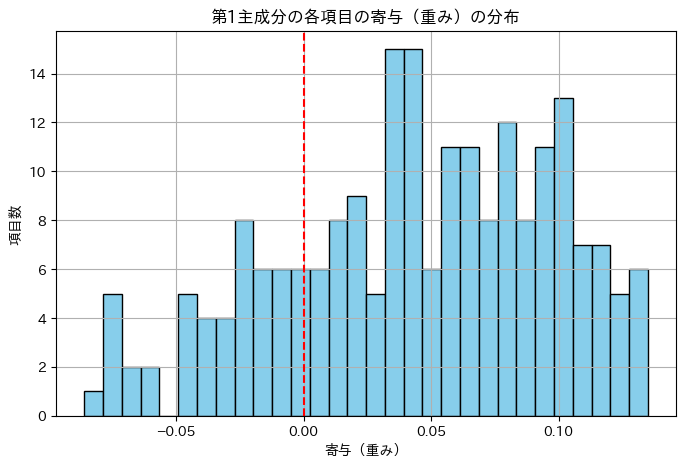

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

# 第1主成分の寄与（重み）の全体的な分布を確認
positive_count = np.sum(pc1_weights > 0)
negative_count = np.sum(pc1_weights < 0)

print(f"全項目数: {len(pc1_weights)}")
print(f"プラスの寄与を持つ項目数: {positive_count}")
print(f"マイナスの寄与を持つ項目数: {negative_count}")

# ヒストグラムで分布を可視化
plt.figure(figsize=(8, 5))
plt.hist(pc1_weights, bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('第1主成分の各項目の寄与（重み）の分布')
plt.xlabel('寄与（重み）')
plt.ylabel('項目数')
plt.grid(True)
plt.show()


この分析結果から明らかなように、全212項目のうち 166項目がプラスの寄与 を持っており、分布全体が右（プラス側）に大きく偏っています。

このことから、第1主成分（PC1）は単なる「食の好みの違い（洋風vs和風など）」だけでなく、**「消費支出全体の規模（たくさんお金を使っているか、あまり使っていないか）」 という総合的な指標（サイズファクター）を表している** 要素が強いと解釈し直すことができます。

つまり、散布図で右側（プラス方向）に位置する都市は、全体的に食料品等に対する支出額が多い傾向にある（物価が高い、またはよく食べる/買う地域）と言えそうです。

### 2-5: 第2主成分の意味の解釈
第2主成分に対する各項目の寄与（重み）を確認し、同様に軸の意味を考察します。

In [ ]:
import pandas as pd

# 第2主成分の固有ベクトル（各特徴量の重み）を取得
pc2_weights = pca.components_[1]

# データフレームにまとめる（item_namesは前のセルで取得済みのものを利用）
df_pc2 = pd.DataFrame({
    '項目コード': df_features_std.columns,
    '項目名': item_names,
    '寄与（重み）': pc2_weights
})

# 寄与が大きい順にソート
df_pc2_sorted = df_pc2.sort_values(by='寄与（重み）', ascending=False)

print("【第2主成分に対してプラスの寄与が大きい項目 トップ10】")
display(df_pc2_sorted.head(10))

print("\n【第2主成分に対してマイナスの寄与が大きい項目 トップ10】")
display(df_pc2_sorted.tail(10))

【第2主成分に対してプラスの寄与が大きい項目 トップ10】


,項目コード,項目名,寄与（重み）
2,LB012002,他のパン,0.158328
48,LB031001,牛肉,0.155161
1,LB012001,食パン,0.154951
51,LB031004,合いびき肉,0.141548
12,LB014003,他の穀類のその他,0.136815
209,LB121201,喫茶代,0.133722
204,LB121106,中華食,0.132944
60,LB042003,バター,0.131156
66,LB051103,はくさい,0.128983
73,LB051202,じゃがいも,0.128351



【第2主成分に対してマイナスの寄与が大きい項目 トップ10】


,項目コード,項目名,寄与（重み）
200,LB121102,中華そば,-0.097021
47,LB024005,他の魚介加工品のその他,-0.098405
32,LB021204,ほたて貝,-0.099745
96,LB052004,わかめ,-0.103314
6,LB013004,中華麺,-0.104093
70,LB051107,もやし,-0.110174
185,LB103002,炭酸飲料,-0.119032
56,LB032004,他の加工肉,-0.129968
7,LB013005,カップ麺,-0.136943
101,LB053003,納豆,-0.142782


出力結果から、第2主成分（PC2）の特徴は以下のように解釈できます。

**【プラス方向の特徴：パン・牛肉・喫茶を中心とした食文化】** 上位には「他のパン」「食パン」といった**パン類**や、「バター」「喫茶代」がランクインしており、**洋風な朝食やカフェ文化**がうかがえます。また「牛肉」「合いびき肉」が上位に来ていることから、肉類の中でも**牛肉を好む文化**（一般的に西日本（関西など）で強い傾向）を表していると考えられます。

**【マイナス方向の特徴：納豆・カップ麺を中心とした手軽・伝統的な食文化】** 一方マイナス方向には「納豆」がトップに来ており、他にも「カップ麺」「中華麺」「もやし」「わかめ」「ほたて貝」などが並んでいます。納豆やほたて貝は**東日本や北日本**で消費量が多い傾向にあります。また、カップ麺や炭酸飲料といった**手軽なジャンクフード的な消費**も特徴として現れています。

**【第2主成分（PC2）の軸の意味】** これらを総合すると、第2主成分の軸は「**パン食・牛肉・喫茶を好む文化（プラス側＝西日本的・都市的）**」と「**納豆・麺類・海産物を好む文化（マイナス側＝東日本的・北日本的）**」の地理的・文化的な違いを色濃く反映していると解釈できそうです。

先ほど作成した散布図（第1主成分 vs 第2主成分）を改めて見てみると、各都市がこの「健康志向 vs 手軽さ（PC1）」「パン・牛肉（西） vs 納豆（東）（PC2）」の2軸のどこに位置しているのかが分かり、非常に興味深い分析になると思います。

### 2-6: クラスタリング結果を用いた散布図の色分け

主成分分析による2次元散布図に、K-means法（ここでは例としてK=4）のクラスタリング結果で色分けを適用します。

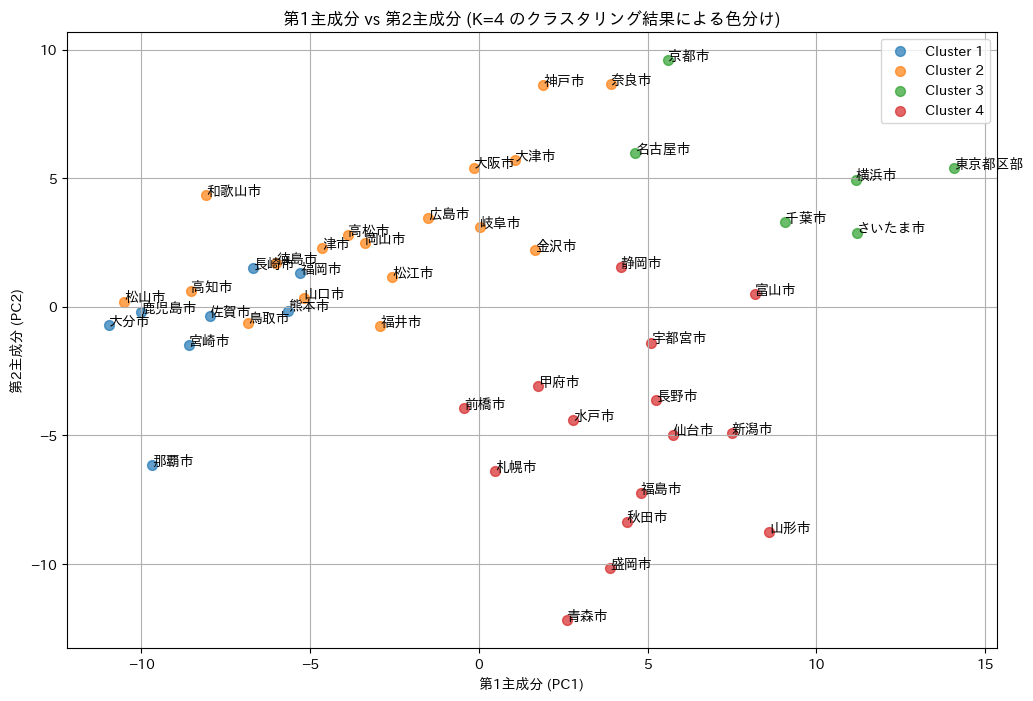

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.cluster import KMeans

# クラスタ数を指定（必要に応じて変更してください）
k = 4

# K-meansクラスタリングを実行
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(df_features_std)

plt.figure(figsize=(12, 8))

# クラスタごとにループを回して散布図をプロット
for i in range(k):
    # 各クラスタに該当するインデックスを取得
    idx = (cluster_labels == i)
    plt.scatter(df_pca.loc[idx, 'PC1'], df_pca.loc[idx, 'PC2'], label=f'Cluster {i+1}', alpha=0.7, s=50)

# 各点に都市名を付記
for i, city in enumerate(cities):
    plt.annotate(city, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10)

plt.title(f'第1主成分 vs 第2主成分 (K={k} のクラスタリング結果による色分け)')
plt.xlabel('第1主成分 (PC1)')
plt.ylabel('第2主成分 (PC2)')
plt.legend()
plt.grid(True)
plt.show()